<!-- Cell purpose: Introduce the unembryonated treatment summary notebook. -->

# Treatment Summary (Unembryonated) (`analysis_sumup_unembryonated.ipynb`)

This notebook compares the selected final treatment groups across 800nm, 400nm (SHG), and UVC using the same workflow conventions as the modality-specific notebooks.

Rules applied:
- Data source: `master_csv/01_master_unembryonated.csv`
- Pooled controls: `2024-03-04`, `2024-03-20`, `2025-06-12`
- Exclude `degenerated` eggs
- Include `arrested` and `leak` eggs up to their last recorded stage
- Selected treatment groups:
  - `800nm pulsed 120s`
  - `400nm SHG 10mW 2s`
  - `UVC 6W 2s`
  - `UVC 6W 5s`



In [1]:
# Import libraries and configure notebook settings

from pathlib import Path
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy import stats

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

sns.set_theme(style="whitegrid", context="talk")

CSV_PATH = "master_csv/01_master_unembryonated.csv"
CONTROL_DATES = [
    pd.Timestamp("2024-03-04"),
    pd.Timestamp("2024-03-20"),
    pd.Timestamp("2025-06-12"),
]

VALID_OUTCOMES = {"l3_reached", "arrested", "leak"}

GROUP_SPECS = [
    {
        "group": "pooled_control",
        "display": "Pooled control",
        "kind": "control",
    },
    {
        "group": "800nm_pulsed_120s",
        "display": "800nm pulsed 120s",
        "kind": "treatment",
        "wl_nm": 800,
        "regime": "pulsed",
        "exposure_s": 120,
    },
    {
        "group": "shg_10mW_2s",
        "display": "400nm SHG 10mW 2s",
        "kind": "treatment",
        "wl_nm": 400,
        "regime": "shg",
        "power_mW": 10,
        "exposure_s": 2,
    },
    {
        "group": "uvc_6W_2s",
        "display": "UVC 6W 2s",
        "kind": "treatment",
        "system": "uvc",
        "wl_nm": 254,
        "power_mW": 6,
        "exposure_s": 2,
    },
    {
        "group": "uvc_6W_5s",
        "display": "UVC 6W 5s",
        "kind": "treatment",
        "system": "uvc",
        "wl_nm": 254,
        "power_mW": 6,
        "exposure_s": 5,
    },
]

GROUP_ORDER = [spec["group"] for spec in GROUP_SPECS]
GROUP_DISPLAY = {spec["group"]: spec["display"] for spec in GROUP_SPECS}
GROUP_DISPLAY_ORDER = [GROUP_DISPLAY[g] for g in GROUP_ORDER]

PLOTS_DIR = Path("cross-modality/unembryonated/plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR = Path("cross-modality/unembryonated/tables")
TABLES_DIR.mkdir(parents=True, exist_ok=True)



In [2]:
# Define helper functions for file lookup and data preparation

def resolve_csv_path(raw_path: str) -> Path:
    raw = Path(raw_path)
    stripped = Path(str(raw_path).replace("LIA-STH-Repo/", "", 1))

    start = Path.cwd().resolve()
    search_bases = [start, *start.parents]

    candidates = [raw, stripped]
    for base in search_bases:
        candidates.append(base / raw)
        candidates.append(base / stripped)

    seen = set()
    for cand in candidates:
        key = str(cand)
        if key in seen:
            continue
        seen.add(key)
        if cand.exists():
            return cand.resolve()

    raise FileNotFoundError(f"CSV not found. Tried: {[str(c) for c in candidates]}")


def to_snake_or_nan(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    s = re.sub(r"[^0-9a-zA-Z]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s if s else np.nan


def mask_for_spec(data: pd.DataFrame, spec: dict) -> pd.Series:
    mask = pd.Series(True, index=data.index)

    if spec.get("kind") == "control":
        mask &= data["control"].eq(1)
        mask &= data["start_date"].isin(CONTROL_DATES)
        return mask

    for key in ["system", "regime", "wl_nm", "power_mW", "exposure_s"]:
        if key in spec:
            mask &= data[key].eq(spec[key])
    return mask



In [3]:
# Load and clean source table

csv_file = resolve_csv_path(CSV_PATH)
df = pd.read_csv(csv_file)

unnamed = [c for c in df.columns if c.lower().startswith("unnamed")]
if unnamed:
    df = df.drop(columns=unnamed)

if "well_#" in df.columns:
    df = df.rename(columns={"well_#": "well_id"})

text_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
for col in text_cols:
    s = df[col].astype("string").str.strip()
    s = s.replace({"NA": pd.NA, "na": pd.NA, "": pd.NA, "None": pd.NA, "none": pd.NA}, regex=False)
    df[col] = s

df["start_date"] = pd.to_datetime(df["start_date"], errors="coerce")
for col in ["system", "regime", "outcome", "flags"]:
    if col in df.columns:
        df[col] = df[col].map(to_snake_or_nan)

for col in ["control", "wl_nm", "power_mW", "irradiance_mW_cm2", "exposure_s", "fluence_J_cm2", "t_start_h", "t_2c_h", "t_4c_h", "t_bean_h", "t_move_h"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Loaded: {csv_file}")
print(f"Rows: {len(df)}")



Loaded: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/master_csv/01_master_unembryonated.csv
Rows: 866


In [4]:
# Selected treatment-group profile table (coverage and stage-time availability)

stage_cols = ["t_2c_h", "t_4c_h", "t_bean_h", "t_move_h"]
rows = []

for spec in GROUP_SPECS:
    mask = mask_for_spec(df, spec)
    sub = df[mask].copy()
    sub_valid = sub[sub["outcome"].isin(VALID_OUTCOMES)].copy()

    stage_non_null = {c: int(sub_valid[c].notna().sum()) for c in stage_cols}
    n_any_stage = int(sub_valid[stage_cols].notna().any(axis=1).sum())

    rows.append(
        {
            "group": spec["group"],
            "group_display": spec["display"],
            "kind": spec.get("kind", "treatment"),
            "n_total": int(len(sub)),
            "n_valid_non_degenerated": int(len(sub_valid)),
            "n_any_stage_time": n_any_stage,
            "n_t_2c": stage_non_null["t_2c_h"],
            "n_t_4c": stage_non_null["t_4c_h"],
            "n_t_bean": stage_non_null["t_bean_h"],
            "n_t_move": stage_non_null["t_move_h"],
            "outcomes_total": dict(sub["outcome"].value_counts(dropna=False)),
            "outcomes_valid": dict(sub_valid["outcome"].value_counts(dropna=False)),
        }
    )

sumup_group_profile_df = pd.DataFrame(rows)
display(sumup_group_profile_df)

missing_groups = sumup_group_profile_df[sumup_group_profile_df["n_valid_non_degenerated"] == 0]["group"].tolist()
if missing_groups:
    raise ValueError(f"No valid rows found for: {missing_groups}")

out_csv = TABLES_DIR / "sumup_selected_group_profile.csv"
sumup_group_profile_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")



,group,group_display,kind,n_total,n_valid_non_degenerated,n_any_stage_time,n_t_2c,n_t_4c,n_t_bean,n_t_move,outcomes_total,outcomes_valid
0,pooled_control,Pooled control,control,97,93,93,93,93,93,93,"{'l3_reached': 93, 'degenerated': 4}",{'l3_reached': 93}
1,800nm_pulsed_120s,800nm pulsed 120s,treatment,36,35,35,35,35,35,35,"{'l3_reached': 35, 'degenerated': 1}",{'l3_reached': 35}
2,shg_10mW_2s,400nm SHG 10mW 2s,treatment,36,35,21,21,18,17,16,"{'l3_reached': 17, 'arrested': 16, 'leak': 2, ...","{'l3_reached': 17, 'arrested': 16, 'leak': 2}"
3,uvc_6W_2s,UVC 6W 2s,treatment,36,31,31,31,31,31,31,"{'l3_reached': 31, 'degenerated': 5}",{'l3_reached': 31}
4,uvc_6W_5s,UVC 6W 5s,treatment,36,33,29,29,29,27,27,"{'l3_reached': 27, 'arrested': 6, 'degenerated...","{'l3_reached': 27, 'arrested': 6}"


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/cross-modality/unembryonated/tables/sumup_selected_group_profile.csv


In [5]:
# Build stage-time analysis table for selected treatments + pooled control

stage_label_map = {
    "dt_2c": "2-cell",
    "dt_4c": "4-cell",
    "dt_bean": "Bean",
    "dt_move": "Motion",
}
stage_order = ["2-cell", "4-cell", "Bean", "Motion"]

frames = []
for spec in GROUP_SPECS:
    sub = df[mask_for_spec(df, spec) & df["outcome"].isin(VALID_OUTCOMES)].copy()
    sub["group"] = spec["group"]
    sub["group_display"] = spec["display"]
    frames.append(sub)

sumup_stage_df = pd.concat(frames, ignore_index=True)
for s in ["2c", "4c", "bean", "move"]:
    sumup_stage_df[f"dt_{s}"] = sumup_stage_df[f"t_{s}_h"] - sumup_stage_df["t_start_h"]

sumup_stage_long_df = (
    sumup_stage_df.melt(
        id_vars=["egg_uid", "well_id", "start_date", "outcome", "group", "group_display"],
        value_vars=["dt_2c", "dt_4c", "dt_bean", "dt_move"],
        var_name="stage",
        value_name="dt_h",
    )
    .dropna(subset=["dt_h"])
    .copy()
)
sumup_stage_long_df["stage"] = sumup_stage_long_df["stage"].map(stage_label_map)
sumup_stage_long_df["stage"] = pd.Categorical(sumup_stage_long_df["stage"], categories=stage_order, ordered=True)
sumup_stage_long_df["group"] = pd.Categorical(sumup_stage_long_df["group"], categories=GROUP_ORDER, ordered=True)
sumup_stage_long_df["group_display"] = pd.Categorical(sumup_stage_long_df["group_display"], categories=GROUP_DISPLAY_ORDER, ordered=True)

display(sumup_stage_long_df.head())
display(sumup_stage_long_df.groupby(["group_display", "stage"], observed=True)["dt_h"].size().reset_index(name="n"))

out_csv = TABLES_DIR / "sumup_stage_times_long_selected_treatments_and_pooled_control.csv"
sumup_stage_long_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")



,egg_uid,well_id,start_date,outcome,group,group_display,stage,dt_h
0,383,1,2024-03-04,l3_reached,pooled_control,Pooled control,2-cell,31.5
1,384,1,2024-03-04,l3_reached,pooled_control,Pooled control,2-cell,29.5
2,385,2,2024-03-04,l3_reached,pooled_control,Pooled control,2-cell,30.5
3,386,2,2024-03-04,l3_reached,pooled_control,Pooled control,2-cell,37.5
4,387,2,2024-03-04,l3_reached,pooled_control,Pooled control,2-cell,38.5


,group_display,stage,n
0,Pooled control,2-cell,93
1,Pooled control,4-cell,93
2,Pooled control,Bean,93
3,Pooled control,Motion,93
4,800nm pulsed 120s,2-cell,35
5,800nm pulsed 120s,4-cell,35
6,800nm pulsed 120s,Bean,35
7,800nm pulsed 120s,Motion,35
8,400nm SHG 10mW 2s,2-cell,21
9,400nm SHG 10mW 2s,4-cell,18


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/cross-modality/unembryonated/tables/sumup_stage_times_long_selected_treatments_and_pooled_control.csv


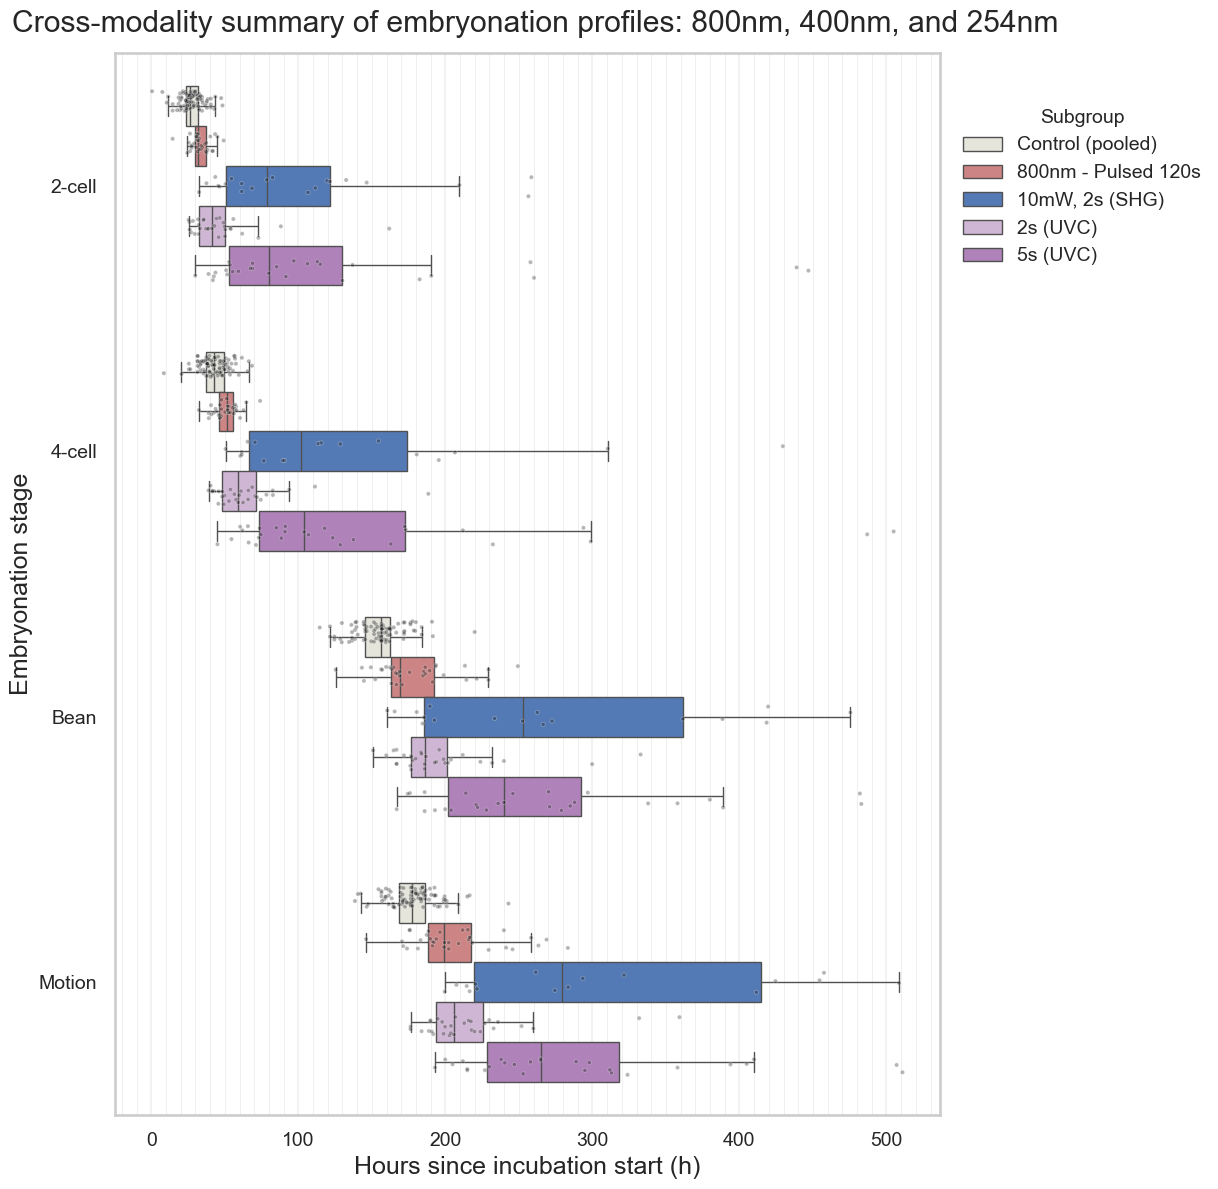

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/cross-modality/unembryonated/plots/boxplot_stage_timing_selected_treatments_vs_pooled_control.png


In [6]:
# Compare stage timing across selected treatments and pooled controls

if "sumup_stage_long_df" not in globals():
    raise ValueError("Run the stage table cell first.")

palette = {
    "Pooled control": "#e6e6db",
    "800nm pulsed 120s": "#d97878",
    "400nm SHG 10mW 2s": "#4477c5",
    "UVC 6W 2s": "#d4b1da",
    "UVC 6W 5s": "#b579c2",
}
point_palette = {k: "#000000" if k == "Pooled control" else "#0A0A0A" for k in GROUP_DISPLAY_ORDER}

legend_label_map = {
    "Pooled control": "Control (pooled)",
    "800nm pulsed 120s": "800nm - Pulsed 120s",
    "400nm SHG 10mW 2s": "10mW, 2s (SHG)",
    "UVC 6W 2s": "2s (UVC)",
    "UVC 6W 5s": "5s (UVC)",
}

plot_df = sumup_stage_long_df.copy()

fig, ax = plt.subplots(figsize=(12, 13))
sns.boxplot(
    data=plot_df,
    x="dt_h",
    y="stage",
    hue="group_display",
    order=stage_order,
    hue_order=GROUP_DISPLAY_ORDER,
    palette=palette,
    showfliers=False,
    linewidth=1.0,
    width=0.75,
    ax=ax,
)

sns.stripplot(
    data=plot_df,
    x="dt_h",
    y="stage",
    hue="group_display",
    order=stage_order,
    hue_order=GROUP_DISPLAY_ORDER,
    palette=point_palette,
    dodge=True,
    jitter=0.2,
    size=3,
    alpha=0.3,
    linewidth=0.6,
    edgecolor="white",
    ax=ax,
)

ax.set_title("")
ax.set_ylabel("Embryonation stage", fontsize=18)
ax.set_xlabel("Hours since incubation start (h)", fontsize=18)
ax.tick_params(axis="both", labelsize=14)
ax.grid(axis="x", alpha=0.25)
ax.xaxis.set_minor_locator(MultipleLocator(10))
ax.grid(axis="x", which="minor", color="#e0e0e0", linewidth=0.4, alpha=0.9)

handles, labels = ax.get_legend_handles_labels()
seen = set()
uniq_handles = []
uniq_labels = []
for h, l in zip(handles, labels):
    if l in seen:
        continue
    seen.add(l)
    uniq_handles.append(h)
    uniq_labels.append(l)

if ax.get_legend() is not None:
    ax.get_legend().remove()

display_labels = [legend_label_map.get(l, l) for l in uniq_labels]
fig.legend(
    uniq_handles,
    display_labels,
    title="Subgroup",
    loc="upper left",
    bbox_to_anchor=(0.85, 0.85),
    frameon=False,
    fontsize=14,
    title_fontsize=14,
    borderaxespad=0.0,
)

fig.suptitle("Cross-modality summary of embryonation profiles: 800nm, 400nm, and 254nm", y=0.92)
plt.tight_layout(rect=[0.04, 0, 0.86, 0.95])
out_png = PLOTS_DIR / "boxplot_stage_timing_selected_treatments_vs_pooled_control.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png.resolve()}")


<!-- Cell purpose: Introduce **Figure 1. Stage timing distributions by treatment subgroup (unembryonated dataset).** Times are measured as hours from incubation start (t_start_h) to each developmental stage (2-cell, 4-cell, Bean, Motion). The pooled control combines experiments started on 2024-03-04, 2024-03-20, and 2025-06-12; treatment subgroups are 800nm pulsed 120s, 400nm SHG 10mW 2s, UVC 6W 2s, and UVC 6W 5s. Only eggs with outcomes l3_reached, arrested, or leak are included, and missing stage times are omitted at the stage level. Boxes show median and interquartile range (IQR), whiskers extend to 1.5x IQR, boxplot fliers are suppressed, and overlaid jittered points show all individual egg measurements (including values beyond whiskers). Right-shifted distributions indicate delayed stage attainment relative to control. -->

**Figure 1. Stage timing distributions by treatment subgroup (unembryonated dataset).** Times are measured as hours from incubation start (`t_start_h`) to each developmental stage (`2-cell`, `4-cell`, `Bean`, `Motion`). The pooled control combines experiments started on `2024-03-04`, `2024-03-20`, and `2025-06-12`; treatment subgroups are `800nm pulsed 120s`, `400nm SHG 10mW 2s`, `UVC 6W 2s`, and `UVC 6W 5s`. Only eggs with outcomes `l3_reached`, `arrested`, or `leak` are included, and missing stage times are omitted at the stage level. Boxes show median and interquartile range (IQR), whiskers extend to 1.5x IQR, boxplot fliers are suppressed, and overlaid jittered points show all individual egg measurements (including values beyond whiskers). Right-shifted distributions indicate delayed stage attainment relative to control.


In [7]:
# Significance across pooled control + selected 800nm/SHG/UVC treatments within each stage (normality-aware omnibus + pairwise tests)

from itertools import combinations

alpha = 0.05

def holm_adjust(pvals: np.ndarray) -> np.ndarray:
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m, dtype=float)
    running = 0.0
    for rank, idx in enumerate(order):
        candidate = pvals[idx] * (m - rank)
        running = max(running, candidate)
        adj[idx] = min(running, 1.0)
    return adj


def p_to_sig(p: float) -> str:
    if np.isnan(p):
        return "NA"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


rows = []
for stage in stage_order:
    sdf = sumup_stage_long_df[sumup_stage_long_df["stage"] == stage].copy()
    groups = [
        sdf.loc[sdf["group"] == g, "dt_h"].dropna().to_numpy(dtype=float)
        for g in GROUP_ORDER
    ]
    sizes = {g: len(arr) for g, arr in zip(GROUP_ORDER, groups)}

    normality_p = {}
    all_groups_normal = True
    for g, arr in zip(GROUP_ORDER, groups):
        if len(arr) < 3:
            normality_p[g] = np.nan
            all_groups_normal = False
            continue
        p_norm = float(stats.shapiro(arr).pvalue)
        normality_p[g] = p_norm
        if p_norm < alpha:
            all_groups_normal = False

    if any(len(arr) == 0 for arr in groups):
        omnibus_test = "NA"
        omnibus_p = np.nan
        pair_method = "NA"
    elif all_groups_normal:
        omnibus_test = "ANOVA"
        omnibus_p = float(stats.f_oneway(*groups).pvalue)
        pair_method = "Welch t-test"
    else:
        omnibus_test = "Kruskal-Wallis"
        omnibus_p = float(stats.kruskal(*groups).pvalue)
        pair_method = "Mann-Whitney U"

    pair_idxs = list(combinations(range(len(GROUP_ORDER)), 2))
    pair_names = []
    raw_stats = []
    raw_ps = []

    for i, j in pair_idxs:
        g1, g2 = groups[i], groups[j]
        name = f"{GROUP_DISPLAY[GROUP_ORDER[i]]} vs {GROUP_DISPLAY[GROUP_ORDER[j]]}"
        pair_names.append(name)
        if len(g1) == 0 or len(g2) == 0:
            raw_stats.append(np.nan)
            raw_ps.append(np.nan)
            continue

        if pair_method == "Welch t-test":
            tst = stats.ttest_ind(g1, g2, equal_var=False, nan_policy="omit")
            raw_stats.append(float(tst.statistic))
            raw_ps.append(float(tst.pvalue))
        elif pair_method == "Mann-Whitney U":
            mw = stats.mannwhitneyu(g1, g2, alternative="two-sided")
            raw_stats.append(float(mw.statistic))
            raw_ps.append(float(mw.pvalue))
        else:
            raw_stats.append(np.nan)
            raw_ps.append(np.nan)

    raw_ps_arr = np.array(raw_ps, dtype=float)
    valid = np.isfinite(raw_ps_arr)
    adj = np.full_like(raw_ps_arr, np.nan)
    if valid.any():
        adj[valid] = holm_adjust(raw_ps_arr[valid])

    for comp, st, p_raw, p_adj in zip(pair_names, raw_stats, raw_ps, adj):
        row = {
            "stage": stage,
            "omnibus_test": omnibus_test,
            "omnibus_p": omnibus_p,
            "omnibus_significant_0.05": bool(np.isfinite(omnibus_p) and omnibus_p < alpha),
            "pairwise_test": pair_method,
            "comparison": comp,
            "statistic": st,
            "p_raw": p_raw,
            "p_holm": p_adj,
            "significant_0.05": bool(np.isfinite(p_adj) and p_adj < alpha),
            "sig": p_to_sig(p_adj),
        }
        for g in GROUP_ORDER:
            row[f"n_{g}"] = sizes.get(g, 0)
            row[f"normality_p_{g}"] = normality_p.get(g, np.nan)
        rows.append(row)

sumup_stage_stats_df = pd.DataFrame(rows).sort_values(["stage", "comparison"]).reset_index(drop=True)
display(sumup_stage_stats_df)

out_csv = TABLES_DIR / "sumup_stage_significance.csv"
sumup_stage_stats_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")



,stage,omnibus_test,omnibus_p,omnibus_significant_0.05,pairwise_test,comparison,statistic,p_raw,p_holm,significant_0.05,...,n_pooled_control,normality_p_pooled_control,n_800nm_pulsed_120s,normality_p_800nm_pulsed_120s,n_shg_10mW_2s,normality_p_shg_10mW_2s,n_uvc_6W_2s,normality_p_uvc_6W_2s,n_uvc_6W_5s,normality_p_uvc_6W_5s
0,2-cell,Kruskal-Wallis,2.247812e-25,True,Mann-Whitney U,400nm SHG 10mW 2s vs UVC 6W 2s,539.5,6.839751e-05,2.735900e-04,True,...,93,0.089128,35,0.358926,21,0.002162,31,3.285925e-07,29,0.000004
1,2-cell,Kruskal-Wallis,2.247812e-25,True,Mann-Whitney U,400nm SHG 10mW 2s vs UVC 6W 5s,294.0,8.441639e-01,8.441639e-01,False,...,93,0.089128,35,0.358926,21,0.002162,31,3.285925e-07,29,0.000004
2,2-cell,Kruskal-Wallis,2.247812e-25,True,Mann-Whitney U,800nm pulsed 120s vs 400nm SHG 10mW 2s,26.0,7.844673e-09,4.706804e-08,True,...,93,0.089128,35,0.358926,21,0.002162,31,3.285925e-07,29,0.000004
3,2-cell,Kruskal-Wallis,2.247812e-25,True,Mann-Whitney U,800nm pulsed 120s vs UVC 6W 2s,300.5,1.915654e-03,3.831309e-03,True,...,93,0.089128,35,0.358926,21,0.002162,31,3.285925e-07,29,0.000004
4,2-cell,Kruskal-Wallis,2.247812e-25,True,Mann-Whitney U,800nm pulsed 120s vs UVC 6W 5s,40.0,3.002447e-10,2.401957e-09,True,...,93,0.089128,35,0.358926,21,0.002162,31,3.285925e-07,29,0.000004
5,2-cell,Kruskal-Wallis,2.247812e-25,True,Mann-Whitney U,Pooled control vs 400nm SHG 10mW 2s,38.0,6.982646e-12,6.284382e-11,True,...,93,0.089128,35,0.358926,21,0.002162,31,3.285925e-07,29,0.000004
6,2-cell,Kruskal-Wallis,2.247812e-25,True,Mann-Whitney U,Pooled control vs 800nm pulsed 120s,894.5,8.975829e-05,2.735900e-04,True,...,93,0.089128,35,0.358926,21,0.002162,31,3.285925e-07,29,0.000004
7,2-cell,Kruskal-Wallis,2.247812e-25,True,Mann-Whitney U,Pooled control vs UVC 6W 2s,431.0,5.568664e-09,3.898064e-08,True,...,93,0.089128,35,0.358926,21,0.002162,31,3.285925e-07,29,0.000004
8,2-cell,Kruskal-Wallis,2.247812e-25,True,Mann-Whitney U,Pooled control vs UVC 6W 5s,49.0,5.532099e-15,5.532099e-14,True,...,93,0.089128,35,0.358926,21,0.002162,31,3.285925e-07,29,0.000004
9,2-cell,Kruskal-Wallis,2.247812e-25,True,Mann-Whitney U,UVC 6W 2s vs UVC 6W 5s,142.0,5.588047e-06,2.794023e-05,True,...,93,0.089128,35,0.358926,21,0.002162,31,3.285925e-07,29,0.000004


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/cross-modality/unembryonated/tables/sumup_stage_significance.csv


In [8]:
# Relevant post-hoc table for stage groups with significant omnibus difference

if "sumup_stage_stats_df" not in globals():
    raise ValueError("Run the stage significance cell first.")

sumup_stage_posthoc_sig_df = sumup_stage_stats_df[
    sumup_stage_stats_df["omnibus_significant_0.05"] & sumup_stage_stats_df["significant_0.05"]
].copy()
sumup_stage_posthoc_sig_df = sumup_stage_posthoc_sig_df.sort_values(["stage", "comparison"]).reset_index(drop=True)

display(sumup_stage_posthoc_sig_df)

out_csv = TABLES_DIR / "sumup_stage_posthoc_significant_rows.csv"
sumup_stage_posthoc_sig_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")



,stage,omnibus_test,omnibus_p,omnibus_significant_0.05,pairwise_test,comparison,statistic,p_raw,p_holm,significant_0.05,...,n_pooled_control,normality_p_pooled_control,n_800nm_pulsed_120s,normality_p_800nm_pulsed_120s,n_shg_10mW_2s,normality_p_shg_10mW_2s,n_uvc_6W_2s,normality_p_uvc_6W_2s,n_uvc_6W_5s,normality_p_uvc_6W_5s
0,2-cell,Kruskal-Wallis,2.247812e-25,True,Mann-Whitney U,400nm SHG 10mW 2s vs UVC 6W 2s,539.5,6.839751e-05,2.735900e-04,True,...,93,0.089128,35,0.358926,21,0.002162,31,3.285925e-07,29,0.000004
1,2-cell,Kruskal-Wallis,2.247812e-25,True,Mann-Whitney U,800nm pulsed 120s vs 400nm SHG 10mW 2s,26.0,7.844673e-09,4.706804e-08,True,...,93,0.089128,35,0.358926,21,0.002162,31,3.285925e-07,29,0.000004
2,2-cell,Kruskal-Wallis,2.247812e-25,True,Mann-Whitney U,800nm pulsed 120s vs UVC 6W 2s,300.5,1.915654e-03,3.831309e-03,True,...,93,0.089128,35,0.358926,21,0.002162,31,3.285925e-07,29,0.000004
3,2-cell,Kruskal-Wallis,2.247812e-25,True,Mann-Whitney U,800nm pulsed 120s vs UVC 6W 5s,40.0,3.002447e-10,2.401957e-09,True,...,93,0.089128,35,0.358926,21,0.002162,31,3.285925e-07,29,0.000004
4,2-cell,Kruskal-Wallis,2.247812e-25,True,Mann-Whitney U,Pooled control vs 400nm SHG 10mW 2s,38.0,6.982646e-12,6.284382e-11,True,...,93,0.089128,35,0.358926,21,0.002162,31,3.285925e-07,29,0.000004
5,2-cell,Kruskal-Wallis,2.247812e-25,True,Mann-Whitney U,Pooled control vs 800nm pulsed 120s,894.5,8.975829e-05,2.735900e-04,True,...,93,0.089128,35,0.358926,21,0.002162,31,3.285925e-07,29,0.000004
6,2-cell,Kruskal-Wallis,2.247812e-25,True,Mann-Whitney U,Pooled control vs UVC 6W 2s,431.0,5.568664e-09,3.898064e-08,True,...,93,0.089128,35,0.358926,21,0.002162,31,3.285925e-07,29,0.000004
7,2-cell,Kruskal-Wallis,2.247812e-25,True,Mann-Whitney U,Pooled control vs UVC 6W 5s,49.0,5.532099e-15,5.532099e-14,True,...,93,0.089128,35,0.358926,21,0.002162,31,3.285925e-07,29,0.000004
8,2-cell,Kruskal-Wallis,2.247812e-25,True,Mann-Whitney U,UVC 6W 2s vs UVC 6W 5s,142.0,5.588047e-06,2.794023e-05,True,...,93,0.089128,35,0.358926,21,0.002162,31,3.285925e-07,29,0.000004
9,4-cell,Kruskal-Wallis,9.443558e-24,True,Mann-Whitney U,400nm SHG 10mW 2s vs UVC 6W 2s,460.0,1.814810e-04,5.444431e-04,True,...,93,0.325852,35,0.766559,18,0.000967,31,1.675090e-06,29,0.000008


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/cross-modality/unembryonated/tables/sumup_stage_posthoc_significant_rows.csv


In [9]:
# Time differences (hours) for post-hoc significant stage comparisons

if "sumup_stage_posthoc_sig_df" not in globals():
    raise ValueError("Run the stage post-hoc cell first.")

rows = []
for _, r in sumup_stage_posthoc_sig_df.iterrows():
    stage = r["stage"]
    g1_name, g2_name = r["comparison"].split(" vs ")

    g1 = sumup_stage_long_df[
        (sumup_stage_long_df["stage"] == stage) & (sumup_stage_long_df["group_display"] == g1_name)
    ]["dt_h"].dropna().to_numpy(dtype=float)
    g2 = sumup_stage_long_df[
        (sumup_stage_long_df["stage"] == stage) & (sumup_stage_long_df["group_display"] == g2_name)
    ]["dt_h"].dropna().to_numpy(dtype=float)

    if len(g1) == 0 or len(g2) == 0:
        continue

    rows.append(
        {
            "stage": stage,
            "comparison": r["comparison"],
            "n_group1": int(len(g1)),
            "n_group2": int(len(g2)),
            "median_group1_h": float(np.median(g1)),
            "median_group2_h": float(np.median(g2)),
            "median_diff_h_(g2-g1)": float(np.median(g2) - np.median(g1)),
            "mean_group1_h": float(np.mean(g1)),
            "mean_group2_h": float(np.mean(g2)),
            "mean_diff_h_(g2-g1)": float(np.mean(g2) - np.mean(g1)),
            "sd_group1_h": float(np.std(g1, ddof=1)) if len(g1) > 1 else np.nan,
            "sd_group2_h": float(np.std(g2, ddof=1)) if len(g2) > 1 else np.nan,
            "p_holm": r["p_holm"],
            "sig": r["sig"],
        }
    )

sumup_stage_sig_diffs_df = pd.DataFrame(rows)
display(sumup_stage_sig_diffs_df)

out_csv = TABLES_DIR / "sumup_stage_significant_time_differences.csv"
sumup_stage_sig_diffs_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")



,stage,comparison,n_group1,n_group2,median_group1_h,median_group2_h,median_diff_h_(g2-g1),mean_group1_h,mean_group2_h,mean_diff_h_(g2-g1),sd_group1_h,sd_group2_h,p_holm,sig
0,2-cell,400nm SHG 10mW 2s vs UVC 6W 2s,21,31,78.5,41.2,-37.3,101.214286,46.629032,-54.585253,68.022895,25.668076,2.735900e-04,***
1,2-cell,800nm pulsed 120s vs 400nm SHG 10mW 2s,35,21,31.9,78.5,46.6,33.040000,101.214286,68.174286,6.671194,68.022895,4.706804e-08,***
2,2-cell,800nm pulsed 120s vs UVC 6W 2s,35,31,31.9,41.2,9.3,33.040000,46.629032,13.589032,6.671194,25.668076,3.831309e-03,**
3,2-cell,800nm pulsed 120s vs UVC 6W 5s,35,29,31.9,79.9,48.0,33.040000,119.196552,86.156552,6.671194,108.199787,2.401957e-09,***
4,2-cell,Pooled control vs 400nm SHG 10mW 2s,93,21,26.6,78.5,51.9,27.446237,101.214286,73.768049,7.999899,68.022895,6.284382e-11,***
5,2-cell,Pooled control vs 800nm pulsed 120s,93,35,26.6,31.9,5.3,27.446237,33.040000,5.593763,7.999899,6.671194,2.735900e-04,***
6,2-cell,Pooled control vs UVC 6W 2s,93,31,26.6,41.2,14.6,27.446237,46.629032,19.182796,7.999899,25.668076,3.898064e-08,***
7,2-cell,Pooled control vs UVC 6W 5s,93,29,26.6,79.9,53.3,27.446237,119.196552,91.750315,7.999899,108.199787,5.532099e-14,***
8,2-cell,UVC 6W 2s vs UVC 6W 5s,31,29,41.2,79.9,38.7,46.629032,119.196552,72.567519,25.668076,108.199787,2.794023e-05,***
9,4-cell,400nm SHG 10mW 2s vs UVC 6W 2s,18,31,102.0,59.1,-42.9,136.722222,64.816129,-71.906093,99.865531,28.482955,5.444431e-04,***


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/cross-modality/unembryonated/tables/sumup_stage_significant_time_differences.csv


In [10]:
# Per-egg stage deltas for pooled control + selected 800nm/SHG/UVC treatments

if "sumup_stage_df" not in globals():
    raise ValueError("Run the stage table build cell first.")

sumup_delta_df = sumup_stage_df.copy()
sumup_delta_df["delta_2c_4c"] = sumup_delta_df["t_4c_h"] - sumup_delta_df["t_2c_h"]
sumup_delta_df["delta_4c_bean"] = sumup_delta_df["t_bean_h"] - sumup_delta_df["t_4c_h"]
sumup_delta_df["delta_bean_move"] = sumup_delta_df["t_move_h"] - sumup_delta_df["t_bean_h"]

sumup_delta_df = sumup_delta_df.sort_values(["group", "start_date", "well_id", "egg_uid"]).reset_index(drop=True)

delta_cols = [
    "group",
    "group_display",
    "start_date",
    "egg_uid",
    "well_id",
    "outcome",
    "delta_2c_4c",
    "delta_4c_bean",
    "delta_bean_move",
]
sumup_delta_table_df = sumup_delta_df[delta_cols].copy()
display(sumup_delta_table_df)

out_csv = TABLES_DIR / "sumup_delta_table_selected_treatments_and_pooled_control.csv"
sumup_delta_table_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")



,group,group_display,start_date,egg_uid,well_id,outcome,delta_2c_4c,delta_4c_bean,delta_bean_move
0,800nm_pulsed_120s,800nm pulsed 120s,2024-07-17,571,1,l3_reached,17.6,139.1,26.0
1,800nm_pulsed_120s,800nm pulsed 120s,2024-07-17,572,1,l3_reached,19.1,173.9,34.0
2,800nm_pulsed_120s,800nm pulsed 120s,2024-07-17,573,1,l3_reached,15.2,115.8,28.0
3,800nm_pulsed_120s,800nm pulsed 120s,2024-07-17,574,2,l3_reached,25.3,132.6,33.0
4,800nm_pulsed_120s,800nm pulsed 120s,2024-07-17,575,2,l3_reached,16.5,149.0,23.0
...,...,...,...,...,...,...,...,...,...
222,uvc_6W_5s,UVC 6W 5s,2025-06-10,790,11,l3_reached,20.2,147.2,19.5
223,uvc_6W_5s,UVC 6W 5s,2025-06-10,791,11,l3_reached,57.4,165.6,20.0
224,uvc_6W_5s,UVC 6W 5s,2025-06-10,792,12,l3_reached,24.6,147.4,27.0
225,uvc_6W_5s,UVC 6W 5s,2025-06-10,793,12,l3_reached,15.6,119.9,18.5


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/cross-modality/unembryonated/tables/sumup_delta_table_selected_treatments_and_pooled_control.csv


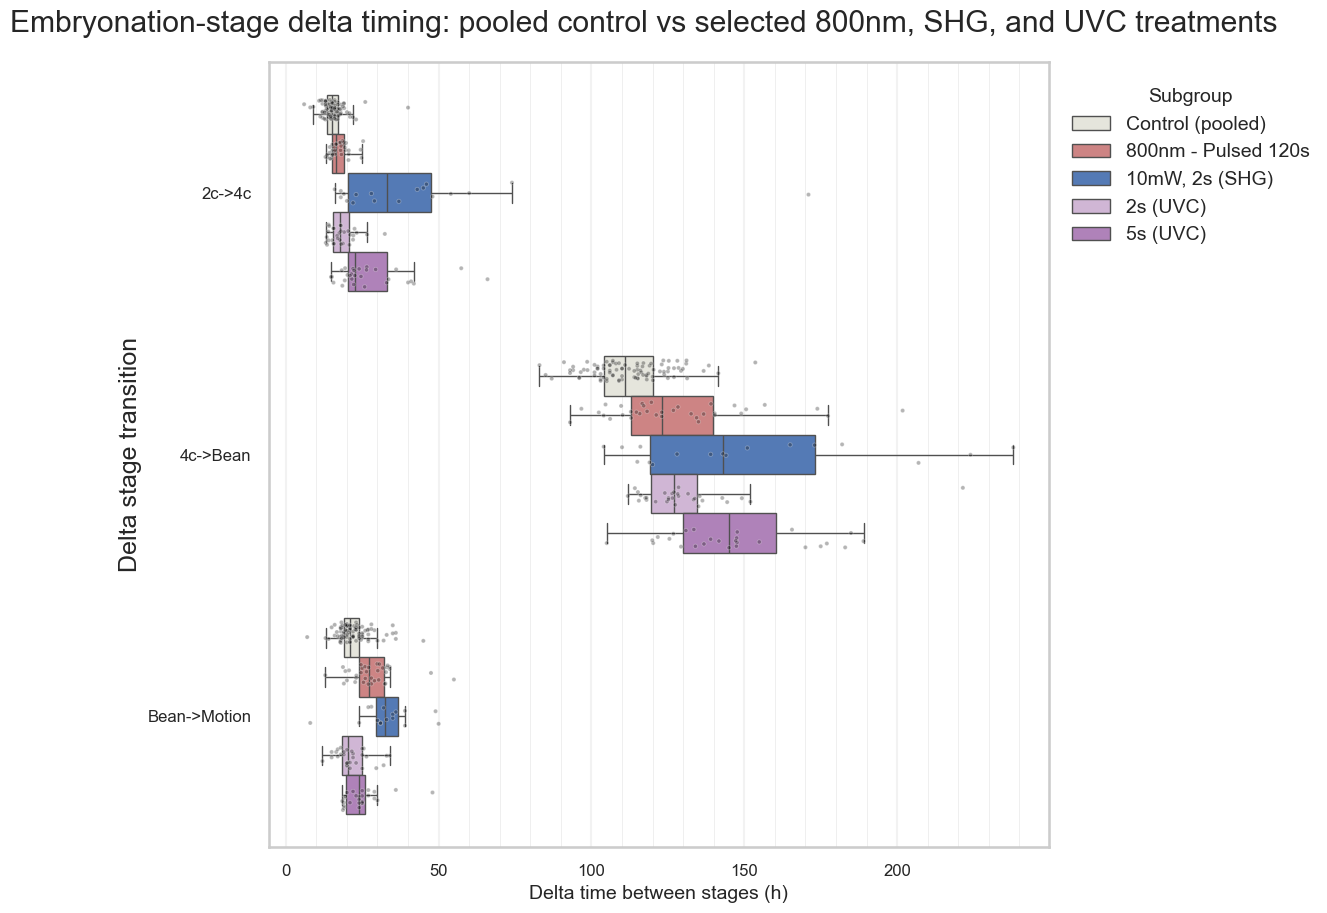

Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/cross-modality/unembryonated/plots/boxplot_delta_timing_selected_treatments_vs_pooled_control.png


In [11]:
# Compare stage-delta timing across selected treatments and pooled controls

if "sumup_delta_table_df" not in globals():
    raise ValueError("Run the delta table cell first.")

delta_stage_map = {
    "delta_2c_4c": "2c->4c",
    "delta_4c_bean": "4c->Bean",
    "delta_bean_move": "Bean->Motion",
}
delta_stage_order = ["2c->4c", "4c->Bean", "Bean->Motion"]

palette = {
    "Pooled control": "#e6e6db",
    "800nm pulsed 120s": "#d97878",
    "400nm SHG 10mW 2s": "#4477c5",
    "UVC 6W 2s": "#d4b1da",
    "UVC 6W 5s": "#b579c2",
}
point_palette = {k: "#000000" if k == "Pooled control" else "#0A0A0A" for k in GROUP_DISPLAY_ORDER}

legend_label_map = {
    "Pooled control": "Control (pooled)",
    "800nm pulsed 120s": "800nm - Pulsed 120s",
    "400nm SHG 10mW 2s": "10mW, 2s (SHG)",
    "UVC 6W 2s": "2s (UVC)",
    "UVC 6W 5s": "5s (UVC)",
}

delta_long = (
    sumup_delta_table_df.melt(
        id_vars=["egg_uid", "well_id", "group", "group_display"],
        value_vars=["delta_2c_4c", "delta_4c_bean", "delta_bean_move"],
        var_name="delta_stage",
        value_name="delta_h",
    )
    .dropna(subset=["delta_h"])
    .copy()
)
delta_long["delta_stage"] = delta_long["delta_stage"].map(delta_stage_map)
delta_long["delta_stage"] = pd.Categorical(delta_long["delta_stage"], categories=delta_stage_order, ordered=True)
delta_long["group"] = pd.Categorical(delta_long["group"], categories=GROUP_ORDER, ordered=True)
delta_long["group_display"] = pd.Categorical(delta_long["group_display"], categories=GROUP_DISPLAY_ORDER, ordered=True)

fig, ax = plt.subplots(figsize=(12, 10))
sns.boxplot(
    data=delta_long,
    x="delta_h",
    y="delta_stage",
    hue="group_display",
    order=delta_stage_order,
    hue_order=GROUP_DISPLAY_ORDER,
    palette=palette,
    showfliers=False,
    linewidth=1.0,
    width=0.75,
    ax=ax,
)

sns.stripplot(
    data=delta_long,
    x="delta_h",
    y="delta_stage",
    hue="group_display",
    order=delta_stage_order,
    hue_order=GROUP_DISPLAY_ORDER,
    palette=point_palette,
    dodge=True,
    jitter=0.2,
    size=3,
    alpha=0.3,
    linewidth=0.6,
    edgecolor="white",
    ax=ax,
)

ax.set_title("")
ax.set_ylabel("Delta stage transition", fontsize=18)
ax.set_xlabel("Delta time between stages (h)", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.grid(axis="x", alpha=0.25)
ax.xaxis.set_minor_locator(MultipleLocator(10))
ax.grid(axis="x", which="minor", color="#e0e0e0", linewidth=0.4, alpha=0.9)

handles, labels = ax.get_legend_handles_labels()
seen = set()
uniq_handles = []
uniq_labels = []
for h, l in zip(handles, labels):
    if l in seen:
        continue
    seen.add(l)
    uniq_handles.append(h)
    uniq_labels.append(l)

if ax.get_legend() is not None:
    ax.get_legend().remove()

display_labels = [legend_label_map.get(l, l) for l in uniq_labels]
fig.legend(
    uniq_handles,
    display_labels,
    title="Subgroup",
    loc="upper left",
    bbox_to_anchor=(0.85, 0.85),
    frameon=False,
    fontsize=14,
    title_fontsize=14,
    borderaxespad=0.0,
)

fig.suptitle("Embryonation-stage delta timing: pooled control vs selected 800nm, SHG, and UVC treatments", y=0.92)
plt.tight_layout(rect=[0.04, 0, 0.86, 0.95])
out_png = PLOTS_DIR / "boxplot_delta_timing_selected_treatments_vs_pooled_control.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png.resolve()}")


<!-- Cell purpose: Introduce **Figure 2. Inter-stage transition durations by treatment subgroup (unembryonated dataset).** Delta times are computed per egg as t_4c_h - t_2c_h (2c->4c), t_bean_h - t_4c_h (4c->Bean), and t_move_h - t_bean_h (Bean->Motion). The same pooled control and selected treatment groups are compared (800nm pulsed 120s, 400nm SHG 10mW 2s, UVC 6W 2s, UVC 6W 5s), restricted to outcomes l3_reached, arrested, and leak. Missing values are excluded for each transition. Boxes show median and IQR, whiskers extend to 1.5x IQR, boxplot fliers are suppressed, and jittered points represent all individual eggs (including values beyond whiskers). Larger rightward shifts and broader spreads indicate slower and/or more heterogeneous transition kinetics. -->

**Figure 2. Inter-stage transition durations by treatment subgroup (unembryonated dataset).** Delta times are computed per egg as `t_4c_h - t_2c_h` (`2c->4c`), `t_bean_h - t_4c_h` (`4c->Bean`), and `t_move_h - t_bean_h` (`Bean->Motion`). The same pooled control and selected treatment groups are compared (`800nm pulsed 120s`, `400nm SHG 10mW 2s`, `UVC 6W 2s`, `UVC 6W 5s`), restricted to outcomes `l3_reached`, `arrested`, and `leak`. Missing values are excluded for each transition. Boxes show median and IQR, whiskers extend to 1.5x IQR, boxplot fliers are suppressed, and jittered points represent all individual eggs (including values beyond whiskers). Larger rightward shifts and broader spreads indicate slower and/or more heterogeneous transition kinetics.


In [12]:
# Significance across pooled control + selected 800nm/SHG/UVC treatments within each delta group (normality-aware omnibus + pairwise tests)

from itertools import combinations

alpha = 0.05
delta_group_order = ["delta_2c_4c", "delta_4c_bean", "delta_bean_move"]


def holm_adjust(pvals: np.ndarray) -> np.ndarray:
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m, dtype=float)
    running = 0.0
    for rank, idx in enumerate(order):
        candidate = pvals[idx] * (m - rank)
        running = max(running, candidate)
        adj[idx] = min(running, 1.0)
    return adj


def p_to_sig(p: float) -> str:
    if np.isnan(p):
        return "NA"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"

rows = []
for dcol in delta_group_order:
    groups = [
        sumup_delta_table_df.loc[sumup_delta_table_df["group"] == g, dcol].dropna().to_numpy(dtype=float)
        for g in GROUP_ORDER
    ]
    sizes = {g: len(arr) for g, arr in zip(GROUP_ORDER, groups)}

    normality_p = {}
    all_groups_normal = True
    for g, arr in zip(GROUP_ORDER, groups):
        if len(arr) < 3:
            normality_p[g] = np.nan
            all_groups_normal = False
            continue
        p_norm = float(stats.shapiro(arr).pvalue)
        normality_p[g] = p_norm
        if p_norm < alpha:
            all_groups_normal = False

    if any(len(arr) == 0 for arr in groups):
        omnibus_test = "NA"
        omnibus_p = np.nan
        pair_method = "NA"
    elif all_groups_normal:
        omnibus_test = "ANOVA"
        omnibus_p = float(stats.f_oneway(*groups).pvalue)
        pair_method = "Welch t-test"
    else:
        omnibus_test = "Kruskal-Wallis"
        omnibus_p = float(stats.kruskal(*groups).pvalue)
        pair_method = "Mann-Whitney U"

    pair_idxs = list(combinations(range(len(GROUP_ORDER)), 2))
    pair_names = []
    raw_stats = []
    raw_ps = []

    for i, j in pair_idxs:
        g1, g2 = groups[i], groups[j]
        name = f"{GROUP_DISPLAY[GROUP_ORDER[i]]} vs {GROUP_DISPLAY[GROUP_ORDER[j]]}"
        pair_names.append(name)

        if len(g1) == 0 or len(g2) == 0:
            raw_stats.append(np.nan)
            raw_ps.append(np.nan)
            continue

        if pair_method == "Welch t-test":
            tst = stats.ttest_ind(g1, g2, equal_var=False, nan_policy="omit")
            raw_stats.append(float(tst.statistic))
            raw_ps.append(float(tst.pvalue))
        elif pair_method == "Mann-Whitney U":
            mw = stats.mannwhitneyu(g1, g2, alternative="two-sided")
            raw_stats.append(float(mw.statistic))
            raw_ps.append(float(mw.pvalue))
        else:
            raw_stats.append(np.nan)
            raw_ps.append(np.nan)

    raw_ps_arr = np.array(raw_ps, dtype=float)
    valid = np.isfinite(raw_ps_arr)
    adj = np.full_like(raw_ps_arr, np.nan)
    if valid.any():
        adj[valid] = holm_adjust(raw_ps_arr[valid])

    for comp, st, p_raw, p_adj in zip(pair_names, raw_stats, raw_ps, adj):
        row = {
            "delta_group": dcol,
            "omnibus_test": omnibus_test,
            "omnibus_p": omnibus_p,
            "omnibus_significant_0.05": bool(np.isfinite(omnibus_p) and omnibus_p < alpha),
            "pairwise_test": pair_method,
            "comparison": comp,
            "statistic": st,
            "p_raw": p_raw,
            "p_holm": p_adj,
            "significant_0.05": bool(np.isfinite(p_adj) and p_adj < alpha),
            "sig": p_to_sig(p_adj),
        }
        for g in GROUP_ORDER:
            row[f"n_{g}"] = sizes.get(g, 0)
            row[f"normality_p_{g}"] = normality_p.get(g, np.nan)
        rows.append(row)

sumup_delta_stats_df = pd.DataFrame(rows).sort_values(["delta_group", "comparison"]).reset_index(drop=True)
display(sumup_delta_stats_df)

out_csv = TABLES_DIR / "sumup_delta_significance.csv"
sumup_delta_stats_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")



,delta_group,omnibus_test,omnibus_p,omnibus_significant_0.05,pairwise_test,comparison,statistic,p_raw,p_holm,significant_0.05,...,n_pooled_control,normality_p_pooled_control,n_800nm_pulsed_120s,normality_p_800nm_pulsed_120s,n_shg_10mW_2s,normality_p_shg_10mW_2s,n_uvc_6W_2s,normality_p_uvc_6W_2s,n_uvc_6W_5s,normality_p_uvc_6W_5s
0,delta_2c_4c,Kruskal-Wallis,5.550456e-17,True,Mann-Whitney U,400nm SHG 10mW 2s vs UVC 6W 2s,483.5,2.314508e-05,1.388705e-04,True,...,93,2.395967e-10,35,0.013159,18,0.000036,31,3.527954e-03,29,0.000175
1,delta_2c_4c,Kruskal-Wallis,5.550456e-17,True,Mann-Whitney U,400nm SHG 10mW 2s vs UVC 6W 5s,332.5,1.202124e-01,2.404248e-01,False,...,93,2.395967e-10,35,0.013159,18,0.000036,31,3.527954e-03,29,0.000175
2,delta_2c_4c,Kruskal-Wallis,5.550456e-17,True,Mann-Whitney U,800nm pulsed 120s vs 400nm SHG 10mW 2s,71.5,5.011803e-06,3.508262e-05,True,...,93,2.395967e-10,35,0.013159,18,0.000036,31,3.527954e-03,29,0.000175
3,delta_2c_4c,Kruskal-Wallis,5.550456e-17,True,Mann-Whitney U,800nm pulsed 120s vs UVC 6W 2s,519.0,7.675815e-01,7.675815e-01,False,...,93,2.395967e-10,35,0.013159,18,0.000036,31,3.527954e-03,29,0.000175
4,delta_2c_4c,Kruskal-Wallis,5.550456e-17,True,Mann-Whitney U,800nm pulsed 120s vs UVC 6W 5s,153.0,1.802409e-06,1.441927e-05,True,...,93,2.395967e-10,35,0.013159,18,0.000036,31,3.527954e-03,29,0.000175
5,delta_2c_4c,Kruskal-Wallis,5.550456e-17,True,Mann-Whitney U,Pooled control vs 400nm SHG 10mW 2s,82.5,1.506204e-09,1.355584e-08,True,...,93,2.395967e-10,35,0.013159,18,0.000036,31,3.527954e-03,29,0.000175
6,delta_2c_4c,Kruskal-Wallis,5.550456e-17,True,Mann-Whitney U,Pooled control vs 800nm pulsed 120s,998.0,7.615151e-04,3.046060e-03,True,...,93,2.395967e-10,35,0.013159,18,0.000036,31,3.527954e-03,29,0.000175
7,delta_2c_4c,Kruskal-Wallis,5.550456e-17,True,Mann-Whitney U,Pooled control vs UVC 6W 2s,859.5,7.797706e-04,3.046060e-03,True,...,93,2.395967e-10,35,0.013159,18,0.000036,31,3.527954e-03,29,0.000175
8,delta_2c_4c,Kruskal-Wallis,5.550456e-17,True,Mann-Whitney U,Pooled control vs UVC 6W 5s,222.0,1.196471e-11,1.196471e-10,True,...,93,2.395967e-10,35,0.013159,18,0.000036,31,3.527954e-03,29,0.000175
9,delta_2c_4c,Kruskal-Wallis,5.550456e-17,True,Mann-Whitney U,UVC 6W 2s vs UVC 6W 5s,165.0,2.652656e-05,1.388705e-04,True,...,93,2.395967e-10,35,0.013159,18,0.000036,31,3.527954e-03,29,0.000175


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/cross-modality/unembryonated/tables/sumup_delta_significance.csv


In [13]:
# Relevant post-hoc table for delta groups with significant omnibus difference

if "sumup_delta_stats_df" not in globals():
    raise ValueError("Run the delta significance cell first.")

sumup_delta_posthoc_sig_df = sumup_delta_stats_df[
    sumup_delta_stats_df["omnibus_significant_0.05"] & sumup_delta_stats_df["significant_0.05"]
].copy()
sumup_delta_posthoc_sig_df = sumup_delta_posthoc_sig_df.sort_values(["delta_group", "comparison"]).reset_index(drop=True)

display(sumup_delta_posthoc_sig_df)

out_csv = TABLES_DIR / "sumup_delta_posthoc_significant_rows.csv"
sumup_delta_posthoc_sig_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")



,delta_group,omnibus_test,omnibus_p,omnibus_significant_0.05,pairwise_test,comparison,statistic,p_raw,p_holm,significant_0.05,...,n_pooled_control,normality_p_pooled_control,n_800nm_pulsed_120s,normality_p_800nm_pulsed_120s,n_shg_10mW_2s,normality_p_shg_10mW_2s,n_uvc_6W_2s,normality_p_uvc_6W_2s,n_uvc_6W_5s,normality_p_uvc_6W_5s
0,delta_2c_4c,Kruskal-Wallis,5.550456e-17,True,Mann-Whitney U,400nm SHG 10mW 2s vs UVC 6W 2s,483.5,2.314508e-05,1.388705e-04,True,...,93,2.395967e-10,35,0.013159,18,0.000036,31,3.527954e-03,29,0.000175
1,delta_2c_4c,Kruskal-Wallis,5.550456e-17,True,Mann-Whitney U,800nm pulsed 120s vs 400nm SHG 10mW 2s,71.5,5.011803e-06,3.508262e-05,True,...,93,2.395967e-10,35,0.013159,18,0.000036,31,3.527954e-03,29,0.000175
2,delta_2c_4c,Kruskal-Wallis,5.550456e-17,True,Mann-Whitney U,800nm pulsed 120s vs UVC 6W 5s,153.0,1.802409e-06,1.441927e-05,True,...,93,2.395967e-10,35,0.013159,18,0.000036,31,3.527954e-03,29,0.000175
3,delta_2c_4c,Kruskal-Wallis,5.550456e-17,True,Mann-Whitney U,Pooled control vs 400nm SHG 10mW 2s,82.5,1.506204e-09,1.355584e-08,True,...,93,2.395967e-10,35,0.013159,18,0.000036,31,3.527954e-03,29,0.000175
4,delta_2c_4c,Kruskal-Wallis,5.550456e-17,True,Mann-Whitney U,Pooled control vs 800nm pulsed 120s,998.0,7.615151e-04,3.046060e-03,True,...,93,2.395967e-10,35,0.013159,18,0.000036,31,3.527954e-03,29,0.000175
5,delta_2c_4c,Kruskal-Wallis,5.550456e-17,True,Mann-Whitney U,Pooled control vs UVC 6W 2s,859.5,7.797706e-04,3.046060e-03,True,...,93,2.395967e-10,35,0.013159,18,0.000036,31,3.527954e-03,29,0.000175
6,delta_2c_4c,Kruskal-Wallis,5.550456e-17,True,Mann-Whitney U,Pooled control vs UVC 6W 5s,222.0,1.196471e-11,1.196471e-10,True,...,93,2.395967e-10,35,0.013159,18,0.000036,31,3.527954e-03,29,0.000175
7,delta_2c_4c,Kruskal-Wallis,5.550456e-17,True,Mann-Whitney U,UVC 6W 2s vs UVC 6W 5s,165.0,2.652656e-05,1.388705e-04,True,...,93,2.395967e-10,35,0.013159,18,0.000036,31,3.527954e-03,29,0.000175
8,delta_4c_bean,Kruskal-Wallis,1.324889e-14,True,Mann-Whitney U,800nm pulsed 120s vs UVC 6W 5s,252.5,1.830884e-03,9.154421e-03,True,...,93,7.694534e-01,35,0.016576,17,0.067318,31,2.769489e-07,27,0.224454
9,delta_4c_bean,Kruskal-Wallis,1.324889e-14,True,Mann-Whitney U,Pooled control vs 400nm SHG 10mW 2s,260.0,1.167012e-05,9.336096e-05,True,...,93,7.694534e-01,35,0.016576,17,0.067318,31,2.769489e-07,27,0.224454


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/cross-modality/unembryonated/tables/sumup_delta_posthoc_significant_rows.csv


In [14]:
# Time differences (hours) for post-hoc significant delta comparisons

if "sumup_delta_posthoc_sig_df" not in globals():
    raise ValueError("Run the delta post-hoc cell first.")

rows = []
for _, r in sumup_delta_posthoc_sig_df.iterrows():
    dcol = r["delta_group"]
    g1_name, g2_name = r["comparison"].split(" vs ")

    g1 = sumup_delta_table_df[sumup_delta_table_df["group_display"] == g1_name][dcol].dropna().to_numpy(dtype=float)
    g2 = sumup_delta_table_df[sumup_delta_table_df["group_display"] == g2_name][dcol].dropna().to_numpy(dtype=float)

    if len(g1) == 0 or len(g2) == 0:
        continue

    rows.append(
        {
            "delta_group": dcol,
            "comparison": r["comparison"],
            "n_group1": int(len(g1)),
            "n_group2": int(len(g2)),
            "median_group1_h": float(np.median(g1)),
            "median_group2_h": float(np.median(g2)),
            "median_diff_h_(g2-g1)": float(np.median(g2) - np.median(g1)),
            "mean_group1_h": float(np.mean(g1)),
            "mean_group2_h": float(np.mean(g2)),
            "mean_diff_h_(g2-g1)": float(np.mean(g2) - np.mean(g1)),
            "sd_group1_h": float(np.std(g1, ddof=1)) if len(g1) > 1 else np.nan,
            "sd_group2_h": float(np.std(g2, ddof=1)) if len(g2) > 1 else np.nan,
            "p_holm": r["p_holm"],
            "sig": r["sig"],
        }
    )

sumup_delta_sig_diffs_df = pd.DataFrame(rows)
display(sumup_delta_sig_diffs_df)

out_csv = TABLES_DIR / "sumup_delta_significant_time_differences.csv"
sumup_delta_sig_diffs_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")



,delta_group,comparison,n_group1,n_group2,median_group1_h,median_group2_h,median_diff_h_(g2-g1),mean_group1_h,mean_group2_h,mean_diff_h_(g2-g1),sd_group1_h,sd_group2_h,p_holm,sig
0,delta_2c_4c,400nm SHG 10mW 2s vs UVC 6W 2s,18,31,33.0,17.7,-15.3,42.833333,18.187097,-24.646237,36.116234,4.264484,1.388705e-04,***
1,delta_2c_4c,800nm pulsed 120s vs 400nm SHG 10mW 2s,35,18,16.5,33.0,16.5,17.502857,42.833333,25.330476,3.135610,36.116234,3.508262e-05,***
2,delta_2c_4c,800nm pulsed 120s vs UVC 6W 5s,35,29,16.5,22.6,6.1,17.502857,27.589655,10.086798,3.135610,12.135495,1.441927e-05,***
3,delta_2c_4c,Pooled control vs 400nm SHG 10mW 2s,93,18,15.0,33.0,18.0,15.533333,42.833333,27.300000,3.902071,36.116234,1.355584e-08,***
4,delta_2c_4c,Pooled control vs 800nm pulsed 120s,93,35,15.0,16.5,1.5,15.533333,17.502857,1.969524,3.902071,3.135610,3.046060e-03,**
5,delta_2c_4c,Pooled control vs UVC 6W 2s,93,31,15.0,17.7,2.7,15.533333,18.187097,2.653763,3.902071,4.264484,3.046060e-03,**
6,delta_2c_4c,Pooled control vs UVC 6W 5s,93,29,15.0,22.6,7.6,15.533333,27.589655,12.056322,3.902071,12.135495,1.196471e-10,***
7,delta_2c_4c,UVC 6W 2s vs UVC 6W 5s,31,29,17.7,22.6,4.9,18.187097,27.589655,9.402558,4.264484,12.135495,1.388705e-04,***
8,delta_4c_bean,800nm pulsed 120s vs UVC 6W 5s,35,27,123.0,145.0,22.0,128.331429,146.151852,17.820423,23.726726,22.318126,9.154421e-03,**
9,delta_4c_bean,Pooled control vs 400nm SHG 10mW 2s,93,17,111.0,143.0,32.0,112.306452,151.647059,39.340607,12.957596,40.964834,9.336096e-05,***


Saved: /Users/arkadi/Desktop/lia-sth/exp_data/data_analysis/cross-modality/unembryonated/tables/sumup_delta_significant_time_differences.csv
